### Quiz 1

Consider $\displaystyle r = \frac{1 + \sqrt{5}}{2}$.

1. Compute a rational approximation for $r$, accurate to 2 decimal places.

2. Verify that the accuracy of your rational approximation is 2 decimal places.

   Write an explanation for your verification.

3. Compute the sequence 
   of the first ten consecutive rational approximations for $r$,
   accurate respectively with 1, 2, up to 10 decimal places (10 included).

#### Answer

**answer to question 1**

In [1]:
r = (1 + sqrt(5))/2
show(r)

1/2*sqrt(5) + 1/2

In [2]:
a = QQ(r.n(digits=2))
show(a)

55/34

**answer to question 2**

In [3]:
err = abs(r - a)/abs(r)
err.n(digits=2)

0.00

In [4]:
err.n(digits=3)

0.000226

We computed in ``err`` the relative error of the approximation ``a`` of the number ``r``.  Evaluated in with 2 decimal places of accuracy, we see that the error is ``0.00``.
Alternatively, evaluate the error with 3 decimal places, we see that the error is $2 \times 10^{-4}$.  Thus, the accuracy of the approximation is (at least) 2 decimal places.

**answer to question 3**

In [5]:
[QQ(r.n(digits=k)) for k in range(1, 11)]

[13/8,
 55/34,
 233/144,
 377/233,
 1597/987,
 4181/2584,
 17711/10946,
 46368/28657,
 196418/121393,
 514229/317811]

### Quiz 2

1. Does $p = x^2 + x + 3$ factor over ${\mathbb Q}[x]$?

   Extend $\mathbb Q$ with a formal root of $p$.  What is the other root of $p$?

2. Make a fast callable object of
   $\displaystyle \frac{x y + 2}{x + y - 1}$
   and draw the expression tree.

#### Answer

**answer to question 1**

In [ ]:
R.<x> = QQ[x]
R

Univariate Polynomial Ring in x over Rational Field

In [ ]:
p = x^2 + x + 3
factor(p)

x^2 + x + 3

We see that $p$ does not factor.

In [ ]:
E.<a> = QQ.extension(p)
E

Number Field in a with defining polynomial x^2 + x + 3

In [ ]:
S.<y> = E[]
S

Univariate Polynomial Ring in y over Number Field in a with defining polynomial x^2 + x + 3

In [ ]:
q = S(p)
q

y^2 + y + 3

In [ ]:
factor(q)

(y - a) * (y + a + 1)

After adding `a` as a root of $p$, we see that $p$ factors over $E = {\mathbb Q}($ `a` $)$.

The other root added is $-$ `a` $-1$.

**answer to question 2**

In [ ]:
from sage.ext.fast_callable import ExpressionTreeBuilder
etb = ExpressionTreeBuilder(vars=['x', 'y'])
x = etb.var('x')
y = etb.var('y')
p = (x*y + 2)/(x + y - 1)
p

div(add(mul(v_0, v_1), 2), sub(add(v_0, v_1), 1))

In [ ]:
f = fast_callable(p)
f.op_list()

[('load_arg', 0),
 ('load_arg', 1),
 'mul',
 ('load_const', 2),
 'add',
 ('load_arg', 0),
 ('load_arg', 1),
 'add',
 ('load_const', 1),
 'sub',
 'div',
 'return']

We start with the leaves of the expression tree.

In [ ]:
Lx = LabelledBinaryTree([None, None], label='v_0')
Ly = LabelledBinaryTree([None, None], label='v_1')
L1 = LabelledBinaryTree([None, None], label='1')
L2 = LabelledBinaryTree([None, None], label='2')

In [ ]:
Nxtimesy = LabelledBinaryTree([Lx, Ly], label='mul')
ascii_art(Nxtimesy)

  _mul_
 /     \
v_0     v_1

In [ ]:
numerator = LabelledBinaryTree([Nxtimesy, L2], label='add')
ascii_art(numerator)

     ___add____
    /          \
  _mul_         2
 /     \        
v_0     v_1     

In [ ]:
Nxplusy = LabelledBinaryTree([Lx, Ly], label='add')
ascii_art(Nxplusy)

  _add_
 /     \
v_0     v_1

In [ ]:
denominator = LabelledBinaryTree([Nxplusy, L1], label='sub')
ascii_art(denominator)

     ___sub____
    /          \
  _add_         1
 /     \        
v_0     v_1     

In [ ]:
tree = LabelledBinaryTree([numerator, denominator], label='div')
ascii_art(tree)

          ________div________
         /                   \
     ___add____            ___sub____
    /          \          /          \
  _mul_         2       _add_         1
 /     \               /     \        
v_0     v_1           v_0     v_1     

### Quiz 3

**Question 1**

Let $\displaystyle \frac{1}{n} \sum_{k=1}^n 
      \ln\left( 1 + \frac{k}{n} \right) \approx \int_0^1 \ln(1 + x) dx$

where ``s = lambda n: float(sum([ln(1 + k/n) for k in range(1, n+1)]))/n``

is a function which defines the approximation for the integral.

1. Time the execution of `s` for $n = 10000$.
      Explain why `s` is inefficient.

2. Apply vectorization to improve the efficiency.  Verify the correctness.

   Time the execution of the vectorized function for $n = 10000$,
   compare with timings of `s`.

#### Answer

**answer to question 1**

In [ ]:
s = lambda n: float(sum([ln(1 + k/n) for k in range(1, n+1)]))/n

In [ ]:
timeit("s(10000)")

5 loops, best of 3: 691 ms per loop

The Python code is inefficient because all calculations are evaluated with exact rational arithmetic and only at the very end is a floating-point approximation computed.

In [ ]:
def vs(n):
    """
    Vectorized version of s.
    """
    from numpy import log, sum, arange
    x = arange(0, n+1)/n
    return sum(log(1+x))/n

Let us first verify the correctness

In [ ]:
s1 = s(10000)
s1

0.38632901806224984

In [ ]:
s2 = vs(10000)
s2

0.38632901806225195

In [ ]:
abs(s1-s2)

2.1094237467877974e-15

The error is about as small as the machine precision.

In [ ]:
timeit("vs(10000)")

625 loops, best of 3: 54.8 μs per loop

We observe a significant drop in execution time, from milliseconds to microseconds.

#### Question 2

Let $p = x^3 + 2 x + 3$ be a polynomial with coefficients
      in the integer number field modulo 17.  
      Is $p$ irreducible over ${\mathbb Z}_{17}$?

Extend the coefficient field with a formal root of $p$
so that, over this extended field, 
$p$ factors into a product of linear polynomials.

#### Answer

**answer to question 2**

In [ ]:
x = polygen(GF(17))
p = x^3 + 2*x + 3
p

x^3 + 2*x + 3

In [ ]:
p.is_irreducible()

False

We see that $p$ is reducible, let us then compute the factors.

In [ ]:
f = factor(p)
f

(x + 1) * (x^2 + 16*x + 3)

To extend ``GF(17)`` with a root of a quadratic factor, we list the factors.

In [ ]:
L = list(f)
L

[(x + 1, 1), (x^2 + 16*x + 3, 1)]

In [ ]:
f1 = L[0][0]
f2 = L[1][0]
(f1, f2)

(x + 1, x^2 + 16*x + 3)

Now we can extend ``GF(17)`` with a root of the quadratic factor.

In [ ]:
E.<a> = GF(17).extension(f2)
E

Finite Field in a of size 17^2

In [ ]:
q = E[x](p)
factor(q)

(x + 1) * (x + a + 16) * (x + 16*a)

After casting $p$ in to the extended number field, we see the three linear factors.

### Quiz 4

mcs 320 quiz 4 Friday 11 July 2025

**Question 1**

Define a piecewise function $f(x)$, defined as follows:

$$
   f(x) = \left\{
     \begin{array}{ccl}
        \sqrt{+x} & & \mbox{if } x > 0 \\
         1       & & \mbox{if } x = 0 \\
        \sqrt{-x} & & \mbox{if } x < 0
     \end{array}
   \right.
$$

Make a plot of $f(x)$ for $x \in [-2, 2]$ to demonstrate your definition of $f$ is correct.

#### Answer

**answer to question 1**

In [ ]:
f(x) = piecewise([((-infinity, 0), sqrt(-x)), ([0,0], 1), ((0, infinity), sqrt(x))])
f

x |--> piecewise(x|-->sqrt(-x) on (-oo, 0), x|-->1 on {0}, x|-->sqrt(x) on (0, +oo); x)

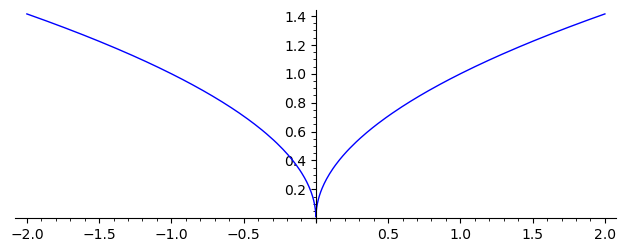

In [ ]:
plot(f(x), (x, -2, 2), aspect_ratio=1)

**Question 2**

Write an efficient recursive function to evaluate
      $a(n) = a(n-1) + a(n-2) + a(n-3)$,
with $a(0) = 0$, $a(1) = 1$, $a(2) = 3$.

Make sure your function can compute $a(100)$.

#### Answer

In [ ]:
reset()

In [ ]:
def a(n, D={}):
    """
    Memoized version of the function a(n).
    """
    if n in D:
        return D[n]
    else:
        if n == 0:
            result = 0
        elif n == 1:
            result = 1
        elif n == 2:
            result = 3
        else:
            result = a(n-1) + a(n-2) + a(n-3)
        D[n] = result
        return result

In [ ]:
[a(k) for k in range(10)]

[0, 1, 3, 4, 8, 15, 27, 50, 92, 169]

In [ ]:
a(100)

204729056034782332665945880

### Quiz 5

MCS 320 Quiz 5 Wednesday 16 July 2025

**Question 1**

Consider 
$\displaystyle f_k(x_1, x_2, \ldots, x_n) = 
 x_{k-1} + 2 x_k - x_{k+1}$, where $x_0 = 0$ and $x_{n+1} = 0$.

Define a function ``F`` which takes on input a list ``X`` of variables
and an index ``k`` in the range of ``X``.
``F(X, k)``  returns $f_k(x_1, x_2, \ldots, x_n)$.

Show that your function works for $n = 8$.

#### Answer

**answer to question 1**

In [ ]:
X = [var('x' + str(k)) for k in range(1, 9)]
X

[x1, x2, x3, x4, x5, x6, x7, x8]

In [ ]:
F = lambda X, k: 2*X[k-1] - (X[k] if k < len(X) else 0) + (X[k-2] if k > 1 else 0)

In [ ]:
for k in range(1, 9):
    print(F(X, k))

2*x1 - x2
x1 + 2*x2 - x3
x2 + 2*x3 - x4
x3 + 2*x4 - x5
x4 + 2*x5 - x6
x5 + 2*x6 - x7
x6 + 2*x7 - x8
x7 + 2*x8


**Question 2**

Compute the slope of the tangent line to the curve
$x^2 - 2 x y + y + 5 = 0$ at the point $(2, 3)$.

#### Answer

**answer to question 2**

In [ ]:
x, y = var('x, y')
curve = x^2 - 2*x*y + y + 5
curve

x^2 - 2*x*y + y + 5

In [ ]:
tc = taylor(curve, (x, 2), (y, 3), 1)
tc

-2*x - 3*y + 13

In [ ]:
slope = -tc.coefficient(x, 1)/tc.coefficient(y, 1)
slope

-2/3

### Quiz 6

MCS 320 Quiz Wednesday 23 July 2025

**Question 1**

Plot $(x^2 + y^2)^3 - 4 x^2 y^2 = 0$ for $x$ and $y$ in $[-1, +1]$.

1. Convert into polar coordinates and plot.

2. Describe the difference between the two plots.

#### Answer

In [ ]:
x, y = var('x, y')
curve = (x^2 + y^2)^3 - 4*x^2*y^2
curve

-4*x^2*y^2 + (x^2 + y^2)^3

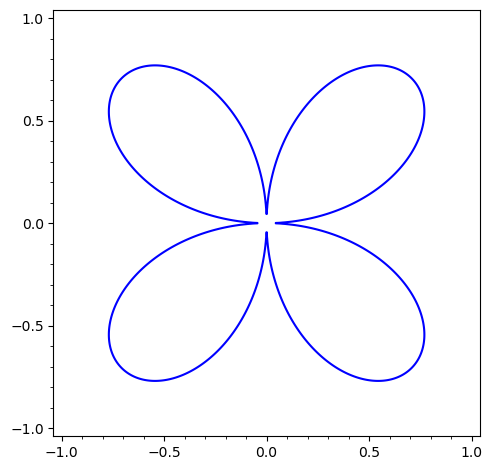

In [ ]:
implicit_plot(curve, (x, -1, 1), (y, -1, 1), plot_points=1000)

Even with 1000 points, the origin does not seem to belong to the curve.

We transform to polar coordinates.

In [ ]:
r, t = var('r, t')
pc = curve(x=r*cos(t), y=r*sin(t))
pc

-4*r^4*cos(t)^2*sin(t)^2 + (r^2*cos(t)^2 + r^2*sin(t)^2)^3

In [ ]:
sol = solve(pc, r)
sol

[r == -2*cos(t)*sin(t)/(cos(t)^2 + sin(t)^2)^(3/2), r == 2*cos(t)*sin(t)/(cos(t)^2 + sin(t)^2)^(3/2), r == 0]

In [ ]:
s0 = sol[0].rhs()
s0

-2*cos(t)*sin(t)/(cos(t)^2 + sin(t)^2)^(3/2)

In [ ]:
f0 = s0.full_simplify()
f0

-2*cos(t)*sin(t)

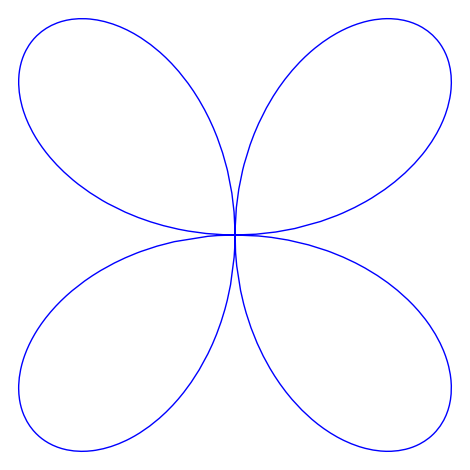

In [ ]:
polar_plot(f0, (t, 0, 2*pi), axes=False)

Compared to the implicit plot, this looks much nicer, without having to require more plot points.

#### Question 2

Consider the polynomial system

$$
  \left\{
    \begin{array}{rcl}
       x^2 - 2 x y + 3 y^3 - 3 & = & 0 \\
       x y + x - 4 & = & 0.
    \end{array}
  \right.
$$

1. Bring the system into triangular form via a Groebner basis.

2. Use the triangular form to justify the number of solutions.

3. Solve the system.

#### Answer

In [ ]:
reset()

In [ ]:
P.<x,y> = PolynomialRing(QQ, order='lex')

In [ ]:
f = [x^2 - 2*x + 3*y^3 - 3, x*y + x - 4]
show(f)

[x^2 - 2*x + 3*y^3 - 3, x*y + x - 4]

In [ ]:
J = Ideal(f)
J

Ideal (x^2 - 2*x + 3*y^3 - 3, x*y + x - 4) of Multivariate Polynomial Ring in x, y over Rational Field

In [ ]:
g = J.groebner_basis()
show(g)

[x + 3/4*y^4 + 3/4*y^3 - 3/4*y - 11/4, y^5 + 2*y^4 + y^3 - y^2 - 14/3*y + 5/3]

From the last two questions, we observe

1. The last equation is a fifth degree polynomial only in $y$, and

2. The second to last equation allows to express $x$ in function of $y$.

So, for each of the five roots of the last equation, we have one corresponding $x$ value.
Therefore, we expect five solutions of the system.  Let us solve the system.

In [ ]:
sols = J.variety(QQbar)
sols

[{y: 1, x: 2},
 {y: -1.961333621253331?, x: -4.160886409844931?},
 {y: 0.3475954037437496?, x: 2.968249957581939?},
 {y: -0.6931308912452093? - 1.401519354728868?*I, x: 0.5963182261314966? + 2.723478876359302?*I},
 {y: -0.6931308912452093? + 1.401519354728868?*I, x: 0.5963182261314966? - 2.723478876359302?*I}]

Indeed, we have five solutions: one is (2, 1), two are real, and two are complex conjugated.

# Project One
Interval arithmetic provides an automated error analysis and helps to decide on the choice of the working precision.  The goal of the project is to explore interval arithmetic in SageMath and to conduct systematically numerical experiments.

# 1. Arithmetic with Intervals

Instances of ``RIF`` are intervals where the lower and upper bounds are elements of ``RR``.

In [ ]:
RIF

Real Interval Field with 53 bits of precision

Even though we are working with 53 bits of precision, we assume only the first five decimal places of the numbers are accurate.  So we have an error of $10^{-5}$ on the numbers.

In [ ]:
e = 1.0e-5

In [ ]:
x = RR.random_element()
x

0.309769031592794

In [ ]:
X = RIF(x-e, x+e)
X

0.3098?

The interval `X` represents $x \pm 10^{-5}$.

In [ ]:
X.str(style='brackets')

'[0.30975903159279388 .. 0.30977903159279391]'

In [ ]:
X.lower()

0.309759031592793

In [ ]:
X.upper()

0.309779031592794

In [ ]:
X.absolute_diameter()

0.0000200000000000200

To illustrate the elementary arithmetical operations, we define another interval `Y`.

In [ ]:
y = RR.random_element()
Y = RIF(y-e, y+e)
Y

0.7474?

In [ ]:
S = X + Y
S

1.0572?

In [ ]:
P = X * Y
P

0.2316?

In [ ]:
Q = X / Y
Q

0.4145?

We see that in the output we can trust the first 4 decimal places.

However, there are instances that lead to a catastrophic loss of accuracy, when we subtract numbers that share several leading bits.

In [ ]:
z = x + RR.random_element()*1.e-4
Z = RIF(z-e,z+e)
S = X-Z
S

0.0001?

In [ ]:
S.absolute_diameter()

0.0000400000000000400

Instead of 4 decimal places of accuracy, we have only one left.

## Assignment One

Generate `X` as above and make `Y` as follows

```
   y = x + f*RR.random_element()
   Y = RIF(y-e, y+e)
```

where `f` takes the values `1.0e-1`, `1.0e-2`,
`1.0e-3`, `1.0e-4`, `1.0e-5`, and `1.0e-6`.

1. For each value of `f`, compute `S = X - Y`
   and report `S.absolute_diameter()`.

2. Write a couple of sentences interpreting the results.

# 2. Algebraic Numbers

An algebraic number is a root of a polynomial equation with integer coefficients.  A feature of the intervals as instances of `RIF` is the `algdep()` method which computes algebraic dependencies.

In [ ]:
r = sqrt(RIF(2-e, 2+e))
r

1.41422?

In [ ]:
r.algdep(1)

29*x - 41

In [ ]:
r.algdep(2)

x^2 - 2

Already a low accuracy approximation for $\sqrt{2}$ suffices to obtain the correct polynomial $x^2 - 2$ which defines the algebraic number $\sqrt{2}$.

## Assignment Two.

Consider $2^{1/8}$, the 8-th root of 2.
What is the smallest number of digits in the floating-point approximation
of $2^{1/8}$ to accurately compute the coefficients of $2 - x^8$,
using the default working precision and tolerance?

# 3. Evaluating a Polynomial

The higher the degree of a polynomial, the more errors accumulate in a numerical evaluation.

In [ ]:
R.<x> = RIF[]
R

Univariate Polynomial Ring in x over Real Interval Field with 53 bits of precision

In [ ]:
p = (1 - x)^6
p

x^6 - 6*x^5 + 15*x^4 - 20*x^3 + 15*x^2 - 6*x + 1

In [ ]:
z = RIF(1.5 - e, 1.5 + e)
z

1.5000?

In [ ]:
pz = p(z)
pz

0.02?

In [ ]:
pz.absolute_diameter()

0.00162749999993883

In [ ]:
pz.lower()

0.0148112472812801

In [ ]:
pz.upper()

0.0164387472812190

In [ ]:
p(3/2)

0.015625000000000000?

With a power of 6, we obtain only one correct decimal in the value when the error is 1.0e-5.

## Assignment Three

Consider

$$
   p(x) = (1 - x)^d, \quad \mbox{for } d = 1,2,\ldots,10,
$$

evaluated at

$$
   Z = [1.5 - 10^{-k}, 1.5 + 10^{+k}], \quad \mbox{for } k = 1,2,\ldots,10.
$$

How does the width of the interval $p(Z)$ change for increasing
values of $d$ and $k$?

1. Report the absolute diameter of the interval $p(Z)$,
   for $d = 1,2,\ldots,10$ and $k=1,2,\ldots,10$ in a table,
   where the rows are indexed by $k$ and the columns by $d$.

2. Compare with the exact value $p(3/2)$ and the error predicted
   by the width of the intervals.

3. Write a couple of sentences interpreting the numerical errors.

> 4. The Deadline is Wednesday 2 July, at 2pm.

Upload your answer to gradescope at the latest on Wednesday 2 July,
before 2pm.

The solution consists of one single notebook,
organized according to the assignments.
Mark the start of each solution to an assignment using a heading in a cell.
Your notebook should run from top to bottom as a program without errors.
Apply proper formatting in your notebook so it reads
like a technical report if you would print it.
Document the execution cells with complete sentences,
properly formatted in markdown cells.

You may (not must) work in pairs for this project.
A pair consists of two, not three or more.
If you decide to work in a pair,
then you must send me an email with the name of your partner and
with the email address of your partner in the copy of the email,
before 2pm on Wednesday 25 June.
If working in a pair, then only one Jupyter notebook should be submitted.

If you have questions, concerns, or difficulties,
feel free to contact me for help.

# Project One - Answers

Interval arithmetic provides an automated error analysis and helps to decide on the choice of the working precision.  The goal of the project is to explore interval arithmetic in SageMath and to conduct systematically numerical experiments.

## 1. Arithmetic with Intervals

Instances of ``RIF`` are intervals where the lower and upper bounds are elements of ``RR``.

In [ ]:
RIF

Real Interval Field with 53 bits of precision

Even though we are working with 53 bits of precision, we assume only the first five decimal places of the numbers are accurate.  So we have an error of $10^{-5}$ on the numbers.

In [ ]:
e = 1.0e-5

In [ ]:
x = RR.random_element()
x

0.0162893269919866

In [ ]:
X = RIF(x-e, x+e)
X

0.0163?

The interval `X` represents $x \pm 10^{-5}$.

In [ ]:
X.str(style='brackets')

'[0.016279326991986597 .. 0.016299326991986597]'

In [ ]:
X.lower()

0.0162793269919865

In [ ]:
X.upper()

0.0162993269919866

In [ ]:
X.absolute_diameter()

0.0000199999999999992

To illustrate the elementary arithmetical operations, we define another interval `Y`.

In [ ]:
y = RR.random_element()
Y = RIF(y-e, y+e)
Y

-0.9427?

In [ ]:
S = X + Y
S

-0.9264?

In [ ]:
P = X * Y
P

-0.0154?

In [ ]:
Q = X / Y
Q

-0.0173?

We see that in the output we can trust the first 4 decimal places.

However, there are instances that lead to a catastrophic loss of accuracy, when we subtract numbers that share several leading bits.

In [ ]:
z = x + RR.random_element()*1.e-4
Z = RIF(z-e,z+e)
S = X-Z
S

-0.0001?

In [ ]:
S.absolute_diameter()

0.0000399999999999984

Instead of 4 decimal places of accuracy, we have only one left.

### Assignment One

Generate `X` as above and make `Y` as follows

```
   y = x + f*RR.random_element()
   Y = RIF(y-e, y+e)
```

where `f` takes the values `1.0e-1`, `1.0e-2`,
`1.0e-3`, `1.0e-4`, `1.0e-5`, and `1.0e-6`.

1. For each value of `f`, compute `S = X - Y`
   and report `S.absolute_diameter()`.

2. Write a couple of sentences interpreting the results.

### Solution to Assignment One

In [ ]:
e = 1.0e-5

In [ ]:
x = RR.random_element()
X = RIF(x-e, x+e)
for f in [1.0e-1, 1.0e-2, 1.0e-3, 1.0e-4, 1.0e-5, 1.0e-6]:
    y = x + f*RR.random_element()
    Y = RIF(y-e, y + e)
    S = X - Y
    print(S, S.absolute_diameter())

-0.0443? 0.0000399999999999984
-0.0073? 0.0000399999999999984
-0.0007? 0.0000399999999999984
0.0000? 0.0000399999999999984
0.0000? 0.0000399999999999984
0.0000? 0.0000399999999999984


As we consider the difference of the intervals, we notice that the difference becomes zero viewed from the error on the accuracy of five decimal places on the numbers.

The absolute diameter represents the absolute error and remains the same.

## 2. Algebraic Numbers

An algebraic number is a root of a polynomial equation with integer coefficients.  A feature of the intervals as instances of `RIF` is the `algdep()` method which computes algebraic dependencies.

In [ ]:
r = sqrt(RIF(2-e, 2+e))
r

1.41422?

In [ ]:
r.algdep(1)

29*x - 41

In [ ]:
r.algdep(2)

x^2 - 2

Already a low accuracy approximation for $\sqrt{2}$ suffices to obtain the correct polynomial $x^2 - 2$ which defines the algebraic number $\sqrt{2}$.

### Assignment Two.

Consider $2^{1/8}$, the 8-th root of 2.
What is the smallest number of digits in the floating-point approximation
of $2^{1/8}$ to accurately compute the coefficients of $2 - x^8$,
using the default working precision and tolerance?

### Solution to Assignment Two

We begin with a large error.

In [ ]:
e = 1.0e-2
e

0.0100000000000000

In [ ]:
r = RIF(2-e,2+e)^(1/8)
r

1.09?

In [ ]:
r.algdep(8)

x^6 + x^5 - x^2 - x - 1

With only 3 decimal places of accuracy in the approximation for $2^{1/8}$, we cannot recover the algebraic dependency correctly.  Let us take then a smaller error.

In [ ]:
e = 1.0e-3
e

0.00100000000000000

In [ ]:
r = RIF(2-e,2+e)^(1/8)
r

1.0905?

In [ ]:
r.algdep(8)

x^8 - 2

Five decimal places of accuracy in the approximation for $2^{1/8}$ suffice to recover the correct algebraic dependency.

## 3. Evaluating a Polynomial

The higher the degree of a polynomial, the more errors accumulate in a numerical evaluation.

In [ ]:
R.<x> = RIF[]
R

Univariate Polynomial Ring in x over Real Interval Field with 53 bits of precision

In [ ]:
p = (1 - x)^6
p

x^6 - 6*x^5 + 15*x^4 - 20*x^3 + 15*x^2 - 6*x + 1

In [ ]:
z = RIF(1.5 - e, 1.5 + e)
z

1.500?

In [ ]:
pz = p(z)
pz

0.0?

In [ ]:
pz.absolute_diameter()

0.162749906000022

In [ ]:
pz.lower()

-0.0657771404872592

In [ ]:
pz.upper()

0.0969727655127633

In [ ]:
p(3/2)

0.015625000000000000?

With a power of 6, we obtain only one correct decimal in the value when the error is 1.0e-5.

### Assignment Three

Consider

$$
   p(x) = (1 - x)^d, \quad \mbox{for } d = 1,2,\ldots,10,
$$

evaluated at

$$
   Z = [1.5 - 10^{-k}, 1.5 + 10^{+k}], \quad \mbox{for } k = 1,2,\ldots,10.
$$

How does the width of the interval $p(Z)$ change for increasing
values of $d$ and $k$?

1. Report the absolute diameter of the interval $p(Z)$,
   for $d = 1,2,\ldots,10$ and $k=1,2,\ldots,10$ in a table,
   where the rows are indexed by $k$ and the columns by $d$.

2. Compare with the exact value $p(3/2)$ and the error predicted
   by the width of the intervals.

3. Write a couple of sentences interpreting the numerical errors.

### Solution to Assignment Three

We start by computing the first table of diameters.

In [ ]:
diam = [[0 for d in range(10)] for k in range(10)]

In [ ]:
for k in range(1, 11):
    for d in range(1, 11):
        p = (1-x)^d
        Z = RIF(1.5 - 1.0/10^k, 1.5 + 1.0/10^k)
        pZ = p(Z)
        diam[k-1][d-1] = pZ.absolute_diameter()

Printing this table unformatted is a mess.  As we are mainly interested in the magnitudes of the numbers, we use scientific notations, using two digits for the exponent.

While the C formatting conversions could be used, the most convenient format is available in numpy.

In [ ]:
import numpy as np

In [ ]:
for k in range(10):
    for d in range(10):
        print(np.format_float_scientific(diam[k][d],unique=False,precision=1), end=' ')
    print('')

2.0e-01 4.0e-01 1.0e+00 2.6e+00 6.8e+00 1.7e+01 4.5e+01 1.1e+02 2.9e+02 7.5e+02 
2.0e-02 4.0e-02 1.0e-01 2.6e-01 6.5e-01 1.6e+00 4.1e+00 1.0e+01 2.6e+01 6.4e+01 
2.0e-03 4.0e-03 1.0e-02 2.6e-02 6.5e-02 1.6e-01 4.1e-01 1.0e+00 2.5e+00 6.4e+00 
2.0e-04 4.0e-04 1.0e-03 2.6e-03 6.5e-03 1.6e-02 4.1e-02 1.0e-01 2.5e-01 6.4e-01 
2.0e-05 4.0e-05 1.0e-04 2.6e-04 6.5e-04 1.6e-03 4.1e-03 1.0e-02 2.5e-02 6.4e-02 
2.0e-06 4.0e-06 1.1e-05 2.6e-05 6.5e-05 1.6e-04 4.1e-04 1.0e-03 2.5e-03 6.4e-03 
2.0e-07 4.0e-07 1.1e-06 2.6e-06 6.5e-06 1.6e-05 4.1e-05 1.0e-04 2.5e-04 6.4e-04 
2.0e-08 4.0e-08 1.1e-07 2.6e-07 6.5e-07 1.6e-06 4.1e-06 1.0e-05 2.5e-05 6.4e-05 
2.0e-09 4.0e-09 1.1e-08 2.6e-08 6.5e-08 1.6e-07 4.1e-07 1.0e-06 2.5e-06 6.4e-06 
2.0e-10 4.0e-10 1.1e-09 2.6e-09 6.5e-09 1.6e-08 4.1e-08 1.0e-07 2.5e-07 6.4e-07 


We observe the following:

1. The smallest diameter occurs at the bottom left of the table, for $k=10$ and $d=1$,
   for a linear polynomial and tiny interval of width $2 \times 10^{-10}$.

2. The largest diameter occurs at the top right of the table, for $k=1$ and $d=10$,
   for a polynomial of degree 10 and a large interval of width $2 \times 10^{-1}$.

3. The diameters grow smaller in each row and larger in each column,
   as the intervals get smaller and the degrees get larger.

The diameter of each evaluated interval serves as a prediction for the error.

Let us compute another table of errors, as the diameters of the exact value subtracted from the evaluated intervals, for increasing degrees and decreasing interval diameters.

In [ ]:
errs = [[0 for d in range(10)] for k in range(10)]

In [ ]:
for k in range(1, 11):
    for d in range(1, 11):
        p = (1-x)^d
        exact = p(x=3/2)
        Z = RIF(1.5 - 1.0/10^k, 1.5 + 1.0/10^k)
        pZ = p(x=Z)
        eZ = pZ - exact
        errs[k-1][d-1] = eZ.absolute_diameter()

In [ ]:
for k in range(10):
    for d in range(10):
        print(np.format_float_scientific(errs[k][d],unique=False,precision=1), end=' ')
    print('')

2.0e-01 4.0e-01 1.0e+00 2.6e+00 6.8e+00 1.7e+01 4.5e+01 1.1e+02 2.9e+02 7.5e+02 
2.0e-02 4.0e-02 1.0e-01 2.6e-01 6.5e-01 1.6e+00 4.1e+00 1.0e+01 2.6e+01 6.4e+01 
2.0e-03 4.0e-03 1.0e-02 2.6e-02 6.5e-02 1.6e-01 4.1e-01 1.0e+00 2.5e+00 6.4e+00 
2.0e-04 4.0e-04 1.0e-03 2.6e-03 6.5e-03 1.6e-02 4.1e-02 1.0e-01 2.5e-01 6.4e-01 
2.0e-05 4.0e-05 1.0e-04 2.6e-04 6.5e-04 1.6e-03 4.1e-03 1.0e-02 2.5e-02 6.4e-02 
2.0e-06 4.0e-06 1.1e-05 2.6e-05 6.5e-05 1.6e-04 4.1e-04 1.0e-03 2.5e-03 6.4e-03 
2.0e-07 4.0e-07 1.1e-06 2.6e-06 6.5e-06 1.6e-05 4.1e-05 1.0e-04 2.5e-04 6.4e-04 
2.0e-08 4.0e-08 1.1e-07 2.6e-07 6.5e-07 1.6e-06 4.1e-06 1.0e-05 2.5e-05 6.4e-05 
2.0e-09 4.0e-09 1.1e-08 2.6e-08 6.5e-08 1.6e-07 4.1e-07 1.0e-06 2.5e-06 6.4e-06 
2.0e-10 4.0e-10 1.1e-09 2.6e-09 6.5e-09 1.6e-08 4.1e-08 1.0e-07 2.5e-07 6.4e-07 


We obtain exactly the same table as before.

The working precision of 53 bits of precision to compute the exact value at 3/2 is sufficient for still modest degrees and for the large diameters of the intervals.

# Project Two
The goal of the project is to apply numerical integration to compute least squares approximations of functions.

# 1. Orthogonal Polynomials

The Chebyshev polynomials form an orthogonal basis with respect to the inner product

$$
    \langle p, q \rangle = \frac{2}{\pi} \int_{-1}^1 \frac{p(x) q(x)}{\sqrt{1-x^2}} dx.
$$

To compute the integrals numerically, we apply the numerical software QUADPACK, wrapped below.

In [ ]:
def inner_product(f, g):
    """
    Wraps quad of scipy.integrate to compute
    the inner product of functions f with g.
    Returns a tuple with the value and an
    estimate of the error.
    """
    from numpy import pi
    from scipy.integrate import quad
    integrand = lambda x: 2.0*f(x)*g(x)/pi
    return quad(integrand,-1,1, limit=100, epsabs=1.0e-12, epsrel=1.0e-12, weight='alg', wvar=(-0.5, -0.5))

For the Chebyshev polynomials $T_i$ and $T_j$ we have

$$
    \langle T_i, T_j \rangle = \left\{
    \begin{array}{ccl}
       2 & \mbox{if} & i = 0 = j, \\
       1 & \mbox{if} & i = j, \\
       0 & \mbox{if} & i \not= j.
    \end{array}
    \right.
$$

Let us verify this property on the first three Chebyshev polynomials.

In [ ]:
T0(x) = chebyshev_T(0, x)
show(T0)

x |--> 1

In [ ]:
inner_product(T0, T0)

(2.000000000000001, 6.437379080603478e-14)

In [ ]:
T1(x) = chebyshev_T(1, x)
show(T1)

x |--> x

In [ ]:
inner_product(T1, T1)

(1.0000000000000007, 7.206724385358528e-14)

In [ ]:
inner_product(T0, T1)

(0.0, 6.782799421513909e-14)

In [ ]:
T2(x) = chebyshev_T(2, x)
show(T2)

x |--> 2*x^2 - 1

In [ ]:
inner_product(T2, T2)

(1.0000000000000004, 1.0880740738678562e-13)

In [ ]:
inner_product(T1, T2)

(0.0, 8.580555286706832e-14)

In [ ]:
inner_product(T0, T2)

(-4.18479521910728e-17, 7.936379416209611e-14)

We will work with the first 10 Chebyshev polynomials, defined in the list below.

In [ ]:
T = [chebyshev_T(k, x) for k in range(10)]
T

[1,
 x,
 2*x^2 - 1,
 4*x^3 - 3*x,
 8*x^4 - 8*x^2 + 1,
 16*x^5 - 20*x^3 + 5*x,
 32*x^6 - 48*x^4 + 18*x^2 - 1,
 64*x^7 - 112*x^5 + 56*x^3 - 7*x,
 128*x^8 - 256*x^6 + 160*x^4 - 32*x^2 + 1,
 256*x^9 - 576*x^7 + 432*x^5 - 120*x^3 + 9*x]

For numerical evaluation, we make fast callable objects of the Chebyshev polynomials.

In [ ]:
f2 = fast_callable(T[2], vars='x')
f2(x)

2*x^2 - 1

In [ ]:
F = [fast_callable(p, vars='x') for p in T]

In [ ]:
[f(x) for f in F]

[1,
 x,
 2*x^2 - 1,
 4*x^3 - 3*x,
 8*x^4 - 8*x^2 + 1,
 16*x^5 - 20*x^3 + 5*x,
 32*x^6 - 48*x^4 + 18*x^2 - 1,
 64*x^7 - 112*x^5 + 56*x^3 - 7*x,
 128*x^8 - 256*x^6 + 160*x^4 - 32*x^2 + 1,
 256*x^9 - 576*x^7 + 432*x^5 - 120*x^3 + 9*x]

In [ ]:
inner_product(F[0],F[0])

(2.000000000000001, 6.437379080603478e-14)

In [ ]:
IPT = []
for f in F:
    IPT.append([inner_product(f, g) for g in F])

To formate the table of inner products nicely, we use scientific formatting, as conveniently provided by numpy.

In [ ]:
from numpy import format_float_scientific as npfmt

In [ ]:
print('the inner products :')
for row in IPT:
    for item in row:
        print(npfmt(item[0], sign=True,unique=False, precision=1), end=' ')
    print('')

the inner products :
+2.0e+00 +0.0e+00 -4.2e-17 +0.0e+00 -1.3e-16 +0.0e+00 -6.7e-16 -1.9e-15 +1.5e-15 +0.0e+00 
+0.0e+00 +1.0e+00 +0.0e+00 +1.4e-17 +0.0e+00 +6.3e-16 +0.0e+00 -1.7e-15 +0.0e+00 +5.7e-15 
-4.2e-17 +0.0e+00 +1.0e+00 +0.0e+00 -2.0e-17 +0.0e+00 -3.5e-16 +0.0e+00 +1.3e-15 +4.5e-17 
+0.0e+00 +1.4e-17 +0.0e+00 +1.0e+00 +0.0e+00 +2.8e-17 +0.0e+00 +1.4e-16 +1.4e-17 +3.4e-15 
-1.3e-16 +0.0e+00 -2.0e-17 +0.0e+00 +1.0e+00 +0.0e+00 +4.7e-16 -3.1e-17 +7.1e-16 +1.5e-16 
+0.0e+00 +6.3e-16 +0.0e+00 +2.8e-17 +0.0e+00 +1.0e+00 +1.4e-17 -5.0e-16 +1.3e-15 +2.1e-15 
-6.7e-16 +0.0e+00 -3.5e-16 +0.0e+00 +4.7e-16 +1.4e-17 +1.0e+00 +0.0e+00 +2.2e-15 -4.0e-16 
-1.9e-15 -1.7e-15 +0.0e+00 +1.4e-16 -3.1e-17 -5.0e-16 +0.0e+00 +1.0e+00 +0.0e+00 +1.7e-15 
+1.5e-15 +0.0e+00 +1.3e-15 +1.4e-17 +7.1e-16 +1.3e-15 +2.2e-15 +0.0e+00 +1.0e+00 +0.0e+00 
+0.0e+00 +5.7e-15 +4.5e-17 +3.4e-15 +1.5e-16 +2.1e-15 -4.0e-16 +1.7e-15 +0.0e+00 +1.0e+00 


We have computed a numerical approximation of the identity matrix, with the exception of the very first element, which equals 2, in agreement with the definition of the inner product.

In [ ]:
print('the error estimates :')
for row in IPT:
    for item in row:
        print(npfmt(item[1], sign=True,unique=False, precision=1), end=' ')
    print('')

the error estimates :
+6.4e-14 +6.8e-14 +7.9e-14 +1.0e-13 +1.5e-13 +2.5e-13 +4.8e-13 +6.0e-13 +2.0e-13 +4.3e-13 
+6.8e-14 +7.2e-14 +8.6e-14 +1.2e-13 +1.8e-13 +3.2e-13 +6.5e-13 +9.5e-13 +4.6e-13 +5.2e-13 
+7.9e-14 +8.6e-14 +1.1e-13 +1.6e-13 +2.8e-13 +5.8e-13 +7.7e-13 +2.8e-13 +4.8e-13 +6.6e-13 
+1.0e-13 +1.2e-13 +1.6e-13 +2.7e-13 +5.6e-13 +7.7e-13 +2.2e-13 +6.2e-13 +6.4e-13 +4.3e-14 
+1.5e-13 +1.8e-13 +2.8e-13 +5.6e-13 +7.6e-13 +2.7e-13 +5.5e-13 +8.4e-13 +4.3e-14 +8.2e-13 
+2.5e-13 +3.2e-13 +5.8e-13 +7.7e-13 +2.7e-13 +5.6e-13 +6.3e-13 +4.1e-14 +8.5e-13 +5.3e-13 
+4.8e-13 +6.5e-13 +7.7e-13 +2.2e-13 +5.5e-13 +6.3e-13 +4.1e-14 +8.5e-13 +5.3e-13 +5.6e-13 
+6.0e-13 +9.5e-13 +2.8e-13 +6.2e-13 +8.4e-13 +4.1e-14 +8.5e-13 +5.3e-13 +9.9e-13 +8.0e-13 
+2.0e-13 +4.6e-13 +4.8e-13 +6.4e-13 +4.3e-14 +8.5e-13 +5.3e-13 +9.9e-13 +8.0e-13 +1.3e-13 
+4.3e-13 +5.2e-13 +6.6e-13 +4.3e-14 +8.2e-13 +5.3e-13 +5.6e-13 +8.0e-13 +1.3e-13 +3.0e-13 


The error estimates are all close enough to the double precision.

# 2. Least Squares Approximations

For any function $f(x)$, we compute an approximation in the Chebyshev basis as

$$
    f(x) = \frac{a_0}{2} + \sum_{k=1}^n a_k T_k(x),
$$

where the coefficients are computed via the inner products:

$$
    a_i = \langle f, T_i \rangle, \quad i = 0, 1, \ldots, n.
$$

By the orthogonality of the Chebyshev basis, the approximation minimizes the square of the errors.

As our first example, let us take the exponential function.

In [ ]:
f(x) = exp(x)

We compute all inner products with the coefficients in the Chebyshev basis.

In [ ]:
ipft = [inner_product(f, T) for T in F]
ipft

[(2.532131755504017, 1.040186253878001e-13),
 (1.13031820798497, 1.1006348135373264e-13),
 (0.2714953395340766, 1.3178963575076938e-13),
 (0.04433684984866379, 1.7857839101954588e-13),
 (0.0054742404420936655, 2.786619721827698e-13),
 (0.0005429263119147293, 5.133024770551932e-13),
 (4.49773229534399e-05, 4.0632208051382745e-14),
 (3.198436462445442e-06, 3.457695298999247e-13),
 (1.9921248281540294e-07, 5.077670324275304e-13),
 (1.1036778269080116e-08, 9.24341447624303e-14)]

All error estimates are again really tiny.  We select the coefficients.

In [ ]:
a = [ip for (ip, err) in ipft]
a

[2.532131755504017,
 1.13031820798497,
 0.2714953395340766,
 0.04433684984866379,
 0.0054742404420936655,
 0.0005429263119147293,
 4.49773229534399e-05,
 3.198436462445442e-06,
 1.9921248281540294e-07,
 1.1036778269080116e-08]

Finally, we can assemble the approximation for the function $f$.

In [ ]:
A = a[0]/2 + sum([a*t for (a, t) in zip(a[1:], T[1:])])
A

(2.82541523688451e-06)*x^9 + (2.5499197800371576e-05)*x^8 + 0.00019834274931351814*x^7 + 0.0013882759389093335*x^6 + 0.008333363995054022*x^5 + 0.04166688603223467*x^4 + 0.16666666118486523*x^3 + 0.49999997254511575*x^2 + 1.0000000002743197*x + 1.0000000005495548

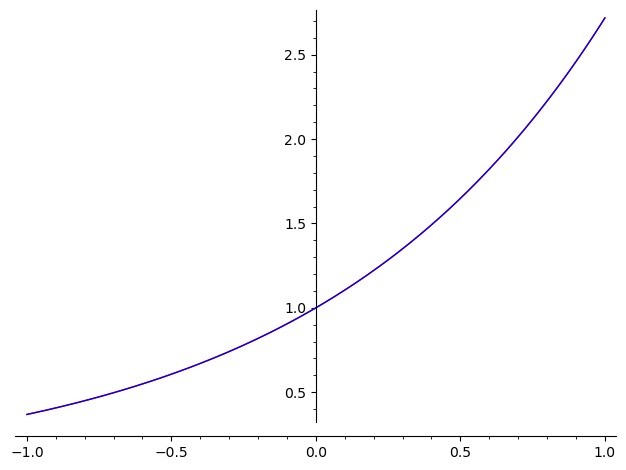

In [ ]:
pA = plot(A, (x, -1, 1), color='red')
pf = plot(f, (x, -1, 1), color='blue')
show(pA + pf)

We see no difference between the approximation and the function itself.

Let us plot the errors.

In [ ]:
errA = lambda z: abs(f(z) - A(x = z))
errA(0)

5.495548460743294e-10

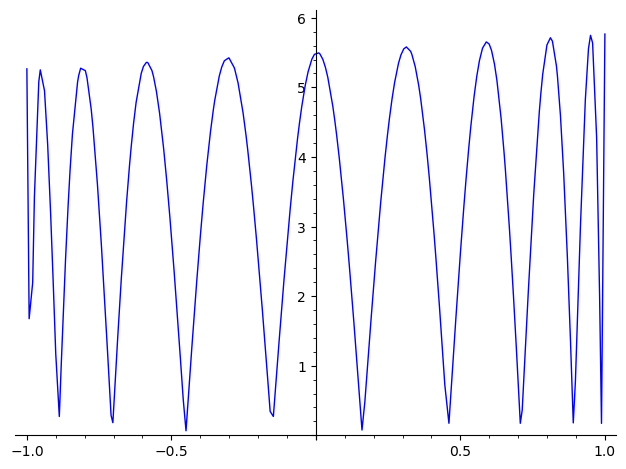

In [ ]:
plot(errA(x), (x, -1, 1), ymax=6.0e-10)

We see that the 9-th degree polynomial approximates $f = \exp(x)$ with an absolute error less than $6 \times 10^{-10}$.

## Assignment One

1. Consider $f(x) = \sin(2 \pi x)$ over $[-1, 1]$.  How many terms in the least squares Chebyshev approximation are needed to obtain an absolute error of $10^{-2}$ over $[-1, 1]$.

2. Compute the smallest number of Chebyshev polynomials needed to get this error.

## Assignment Two

1. Consider $f(x) = \sin(2 \pi x)$ over $[-1,+1]$.  Use the first 16 Chebyshev polynomials to compute a least squares approximation for $f$.

2. What is the error?

# 3. Shifted Chebyshev polynomials

For functions that have a singularity in the middle of $[-1,+1]$,
such as $\sqrt{x}$,
it is better to consider $[0, 1]$ as the interval and work with
shifted Chebyshev polynomials.

The shifted Chebyshev polynomials are $T_n^*(x) = T_n(2 x - 1)$,
defined over the interval $[0,1]$, forming an orthogonal basis
with respect to the weight

$$
    w(x) = \frac{1}{\sqrt{x-x^2}}.
$$

## Assignment Three

1. Define the sequence of the first 10 shifted Chebyshev polynomials and their corresponding list of fast callables.

2. Adjust the function ``inner_product`` into a new function ``shifted_inner_product``, changing the integration interval from $[-1,+1]$ into $[0, 1]$.

3. Verify the orthogonality of the basis by computing the 10-by-10 table of all inner products, along with the estimates for the errors. 

## Assignment Four

1. Consider $f(x) = \exp{x}$ and use the first 16 shifted Chebyshev polynomials to compute a least squares approximation for $f$ over $[0, 1]$.  

2. What is the error?  Compare with the error of the least squares approximation in the Chebyshev basis for $f$ over $[-1, 1]$.

## Assignment Five

1. Consider $f(x) = \sqrt{x}$ and use the first 16 shifted Chebyshev polynomials to compute a least squares approximation for $f$.

2. What is the error?

# Project Two - Answers

The goal of the project is to apply numerical integration to compute least squares approximations of functions.

## 1. Orthogonal Polynomials

The Chebyshev polynomials form an orthogonal basis with respect to the inner product

$$
    \langle p, q \rangle = \frac{2}{\pi} \int_{-1}^1 \frac{p(x) q(x)}{\sqrt{1-x^2}} dx.
$$

To compute the integrals numerically, we apply the numerical software QUADPACK, wrapped below.

In [ ]:
def inner_product(f, g):
    """
    Wraps quad of scipy.integrate to compute
    the inner product of functions f with g.
    Returns a tuple with the value and an
    estimate of the error.
    """
    from numpy import pi
    from scipy.integrate import quad
    integrand = lambda x: 2.0*f(x)*g(x)/pi
    return quad(integrand,-1,1, limit=100, epsabs=1.0e-12, epsrel=1.0e-12, weight='alg', wvar=(-0.5, -0.5))

For the Chebyshev polynomials $T_i$ and $T_j$ we have

$$
    \langle T_i, T_j \rangle = \left\{
    \begin{array}{ccl}
       2 & \mbox{if} & i = 0 = j, \\
       1 & \mbox{if} & i = j, \\
       0 & \mbox{if} & i \not= j.
    \end{array}
    \right.
$$

Let us verify this property on the first three Chebyshev polynomials.

In [ ]:
T0(x) = chebyshev_T(0, x)
show(T0)

x |--> 1

In [ ]:
inner_product(T0, T0)

(2.000000000000001, 6.437379080603478e-14)

In [ ]:
T1(x) = chebyshev_T(1, x)
show(T1)

x |--> x

In [ ]:
inner_product(T1, T1)

(1.0000000000000007, 7.206724385358528e-14)

In [ ]:
inner_product(T0, T1)

(0.0, 6.782799421513909e-14)

In [ ]:
T2(x) = chebyshev_T(2, x)
show(T2)

x |--> 2*x^2 - 1

In [ ]:
inner_product(T2, T2)

(1.0000000000000004, 1.0880740738678562e-13)

In [ ]:
inner_product(T1, T2)

(0.0, 8.580555286706832e-14)

In [ ]:
inner_product(T0, T2)

(-4.18479521910728e-17, 7.936379416209611e-14)

We will work with the first 10 Chebyshev polynomials, defined in the list below.

In [ ]:
T = [chebyshev_T(k, x) for k in range(10)]
T

[1,
 x,
 2*x^2 - 1,
 4*x^3 - 3*x,
 8*x^4 - 8*x^2 + 1,
 16*x^5 - 20*x^3 + 5*x,
 32*x^6 - 48*x^4 + 18*x^2 - 1,
 64*x^7 - 112*x^5 + 56*x^3 - 7*x,
 128*x^8 - 256*x^6 + 160*x^4 - 32*x^2 + 1,
 256*x^9 - 576*x^7 + 432*x^5 - 120*x^3 + 9*x]

For numerical evaluation, we make fast callable objects of the Chebyshev polynomials.

In [ ]:
f2 = fast_callable(T[2], vars='x')
f2(x)

2*x^2 - 1

In [ ]:
F = [fast_callable(p, vars='x') for p in T]

In [ ]:
[f(x) for f in F]

[1,
 x,
 2*x^2 - 1,
 4*x^3 - 3*x,
 8*x^4 - 8*x^2 + 1,
 16*x^5 - 20*x^3 + 5*x,
 32*x^6 - 48*x^4 + 18*x^2 - 1,
 64*x^7 - 112*x^5 + 56*x^3 - 7*x,
 128*x^8 - 256*x^6 + 160*x^4 - 32*x^2 + 1,
 256*x^9 - 576*x^7 + 432*x^5 - 120*x^3 + 9*x]

In [ ]:
inner_product(F[0],F[0])

(2.000000000000001, 6.437379080603478e-14)

In [ ]:
IPT = []
for f in F:
    IPT.append([inner_product(f, g) for g in F])

To formate the table of inner products nicely, we use scientific formatting, as conveniently provided by numpy.

In [ ]:
from numpy import format_float_scientific as npfmt

In [ ]:
print('the inner products :')
for row in IPT:
    for item in row:
        print(npfmt(item[0], sign=True,unique=False, precision=1), end=' ')
    print('')

the inner products :
+2.0e+00 +0.0e+00 -4.2e-17 +0.0e+00 -1.3e-16 +0.0e+00 -6.7e-16 -1.9e-15 +1.5e-15 +0.0e+00 
+0.0e+00 +1.0e+00 +0.0e+00 +1.4e-17 +0.0e+00 +6.3e-16 +0.0e+00 -1.7e-15 +0.0e+00 +5.7e-15 
-4.2e-17 +0.0e+00 +1.0e+00 +0.0e+00 -2.0e-17 +0.0e+00 -3.5e-16 +0.0e+00 +1.3e-15 +4.5e-17 
+0.0e+00 +1.4e-17 +0.0e+00 +1.0e+00 +0.0e+00 +2.8e-17 +0.0e+00 +1.4e-16 +1.4e-17 +3.4e-15 
-1.3e-16 +0.0e+00 -2.0e-17 +0.0e+00 +1.0e+00 +0.0e+00 +4.7e-16 -3.1e-17 +7.1e-16 +1.5e-16 
+0.0e+00 +6.3e-16 +0.0e+00 +2.8e-17 +0.0e+00 +1.0e+00 +1.4e-17 -5.0e-16 +1.3e-15 +2.1e-15 
-6.7e-16 +0.0e+00 -3.5e-16 +0.0e+00 +4.7e-16 +1.4e-17 +1.0e+00 +0.0e+00 +2.2e-15 -4.0e-16 
-1.9e-15 -1.7e-15 +0.0e+00 +1.4e-16 -3.1e-17 -5.0e-16 +0.0e+00 +1.0e+00 +0.0e+00 +1.7e-15 
+1.5e-15 +0.0e+00 +1.3e-15 +1.4e-17 +7.1e-16 +1.3e-15 +2.2e-15 +0.0e+00 +1.0e+00 +0.0e+00 
+0.0e+00 +5.7e-15 +4.5e-17 +3.4e-15 +1.5e-16 +2.1e-15 -4.0e-16 +1.7e-15 +0.0e+00 +1.0e+00 


We have computed a numerical approximation of the identity matrix, with the exception of the very first element, which equals 2, in agreement with the definition of the inner product.

In [ ]:
print('the error estimates :')
for row in IPT:
    for item in row:
        print(npfmt(item[1], sign=True,unique=False, precision=1), end=' ')
    print('')

the error estimates :
+6.4e-14 +6.8e-14 +7.9e-14 +1.0e-13 +1.5e-13 +2.5e-13 +4.8e-13 +6.0e-13 +2.0e-13 +4.3e-13 
+6.8e-14 +7.2e-14 +8.6e-14 +1.2e-13 +1.8e-13 +3.2e-13 +6.5e-13 +9.5e-13 +4.6e-13 +5.2e-13 
+7.9e-14 +8.6e-14 +1.1e-13 +1.6e-13 +2.8e-13 +5.8e-13 +7.7e-13 +2.8e-13 +4.8e-13 +6.6e-13 
+1.0e-13 +1.2e-13 +1.6e-13 +2.7e-13 +5.6e-13 +7.7e-13 +2.2e-13 +6.2e-13 +6.4e-13 +4.3e-14 
+1.5e-13 +1.8e-13 +2.8e-13 +5.6e-13 +7.6e-13 +2.7e-13 +5.5e-13 +8.4e-13 +4.3e-14 +8.2e-13 
+2.5e-13 +3.2e-13 +5.8e-13 +7.7e-13 +2.7e-13 +5.6e-13 +6.3e-13 +4.1e-14 +8.5e-13 +5.3e-13 
+4.8e-13 +6.5e-13 +7.7e-13 +2.2e-13 +5.5e-13 +6.3e-13 +4.1e-14 +8.5e-13 +5.3e-13 +5.6e-13 
+6.0e-13 +9.5e-13 +2.8e-13 +6.2e-13 +8.4e-13 +4.1e-14 +8.5e-13 +5.3e-13 +9.9e-13 +8.0e-13 
+2.0e-13 +4.6e-13 +4.8e-13 +6.4e-13 +4.3e-14 +8.5e-13 +5.3e-13 +9.9e-13 +8.0e-13 +1.3e-13 
+4.3e-13 +5.2e-13 +6.6e-13 +4.3e-14 +8.2e-13 +5.3e-13 +5.6e-13 +8.0e-13 +1.3e-13 +3.0e-13 


The error estimates are all close enough to the double precision.

## 2. Least Squares Approximations

For any function $f(x)$, we compute an approximation in the Chebyshev basis as

$$
    f(x) = \frac{a_0}{2} + \sum_{k=1}^n a_k T_k(x),
$$

where the coefficients are computed via the inner products:

$$
    a_i = \langle f, T_i \rangle, \quad i = 0, 1, \ldots, n.
$$

By the orthogonality of the Chebyshev basis, the approximation minimizes the square of the errors.

As our first example, let us take the exponential function.

In [ ]:
f(x) = exp(x)

We compute all inner products with the coefficients in the Chebyshev basis.

In [ ]:
ipft = [inner_product(f, T) for T in F]
ipft

[(2.532131755504017, 1.040186253878001e-13),
 (1.13031820798497, 1.1006348135373264e-13),
 (0.2714953395340766, 1.3178963575076938e-13),
 (0.04433684984866379, 1.7857839101954588e-13),
 (0.0054742404420936655, 2.786619721827698e-13),
 (0.0005429263119147293, 5.133024770551932e-13),
 (4.49773229534399e-05, 4.0632208051382745e-14),
 (3.198436462445442e-06, 3.457695298999247e-13),
 (1.9921248281540294e-07, 5.077670324275304e-13),
 (1.1036778269080116e-08, 9.24341447624303e-14)]

All error estimates are again really tiny.  We select the coefficients.

In [ ]:
a = [ip for (ip, err) in ipft]
a

[2.532131755504017,
 1.13031820798497,
 0.2714953395340766,
 0.04433684984866379,
 0.0054742404420936655,
 0.0005429263119147293,
 4.49773229534399e-05,
 3.198436462445442e-06,
 1.9921248281540294e-07,
 1.1036778269080116e-08]

Finally, we can assemble the approximation for the function $f$.

In [ ]:
A = a[0]/2 + sum([a*t for (a, t) in zip(a[1:], T[1:])])
A

(2.82541523688451e-06)*x^9 + (2.5499197800371576e-05)*x^8 + 0.00019834274931351814*x^7 + 0.0013882759389093335*x^6 + 0.008333363995054022*x^5 + 0.04166688603223467*x^4 + 0.16666666118486523*x^3 + 0.49999997254511575*x^2 + 1.0000000002743197*x + 1.0000000005495548

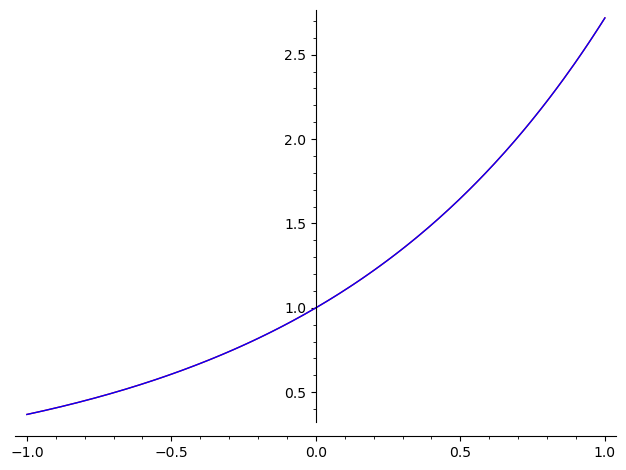

In [ ]:
pA = plot(A, (x, -1, 1), color='red')
pf = plot(f, (x, -1, 1), color='blue')
show(pA + pf)

We see no difference between the approximation and the function itself.

Let us plot the errors.

In [ ]:
errA = lambda z: abs(f(z) - A(x = z))
errA(0)

5.495548460743294e-10

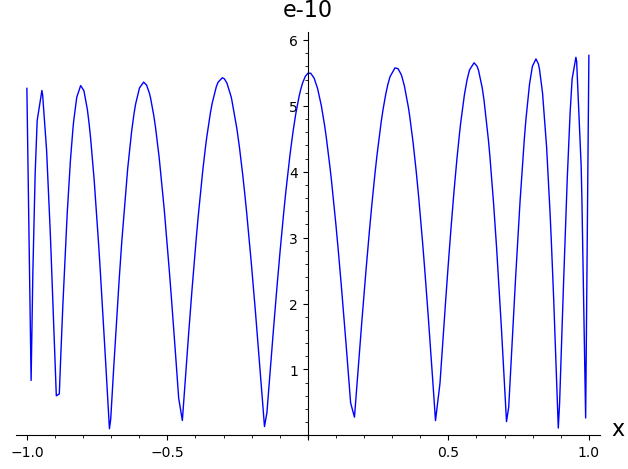

In [ ]:
plot(errA(x), (x, -1, 1), ymax=6.0e-10, axes_labels=['x', 'e-10'])

We see that the 9-th degree polynomial approximates $f = \exp(x)$ with an absolute error less than $6 \times 10^{-10}$.

### Assignment One

1. Consider $f(x) = \sin(2 \pi x)$ over $[-1, 1]$.  How many terms in the least squares Chebyshev approximation are needed to obtain an absolute error of $10^{-2}$ over $[-1, 1]$.

2. Compute the smallest number of Chebyshev polynomials needed to get this error.

### solution to assignment one

In [ ]:
f(x) = sin(2*pi*x)

Let us select the first ten Chebyshev polynomials.

In [ ]:
ipft = [inner_product(f, T) for T in F]
ipft

[(0.0, 7.459000730499313e-15),
 (-0.4247650601527382, 1.7577840453197936e-14),
 (0.0, 9.082313396718633e-14),
 (-0.0582243920785146, 1.1347219099760717e-13),
 (0.0, 9.438212791613082e-13),
 (0.7456493159369406, 5.733434279864011e-15),
 (0.0, 6.712466112689804e-15),
 (-0.315042260224786, 9.93701217291686e-15),
 (0.0, 3.3909277583292514e-14),
 (0.05824776827954421, 9.869219843353269e-14)]

In [ ]:
a = [ip for (ip, err) in ipft]
a

[0.0,
 -0.4247650601527382,
 0.0,
 -0.0582243920785146,
 0.0,
 0.7456493159369406,
 0.0,
 -0.315042260224786,
 0.0,
 0.05824776827954421]

In [ ]:
A = a[0]/2 + sum([a*t for (a, t) in zip(a[1:], T[1:])])
A

14.911428679563318*x^9 - 53.71341918340377*x^7 + 72.37815809693018*x^5 - 39.7779826531862*x^3 + 6.207680431856909*x

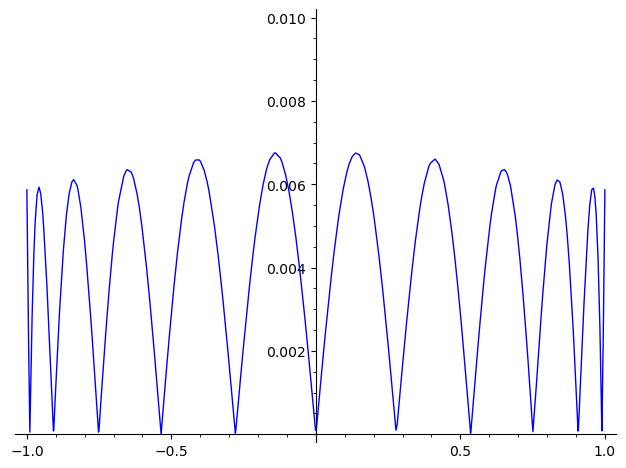

In [ ]:
errA = lambda z: abs(f(z) - A(x = z))
plot(errA(x), (x, -1, 1), ymax=0.01)

Can we get away with less?  Observe that $\sin$ is an odd function, the even degrees are missing.  So we select the first 8 polynomials in the basis.

In [ ]:
ipft = [inner_product(f, T) for T in F[:8]]
ipft

[(0.0, 7.459000730499313e-15),
 (-0.4247650601527382, 1.7577840453197936e-14),
 (0.0, 9.082313396718633e-14),
 (-0.0582243920785146, 1.1347219099760717e-13),
 (0.0, 9.438212791613082e-13),
 (0.7456493159369406, 5.733434279864011e-15),
 (0.0, 6.712466112689804e-15),
 (-0.315042260224786, 9.93701217291686e-15)]

In [ ]:
a = [ip for (ip, err) in ipft]
a

[0.0,
 -0.4247650601527382,
 0.0,
 -0.0582243920785146,
 0.0,
 0.7456493159369406,
 0.0,
 -0.315042260224786]

In [ ]:
A = a[0]/2 + sum([a*t for (a, t) in zip(a[1:8], T[1:8])])
A

-20.162704654386303*x^7 + 47.21512220016709*x^5 - 32.78825045964089*x^3 + 5.6834505173410115*x

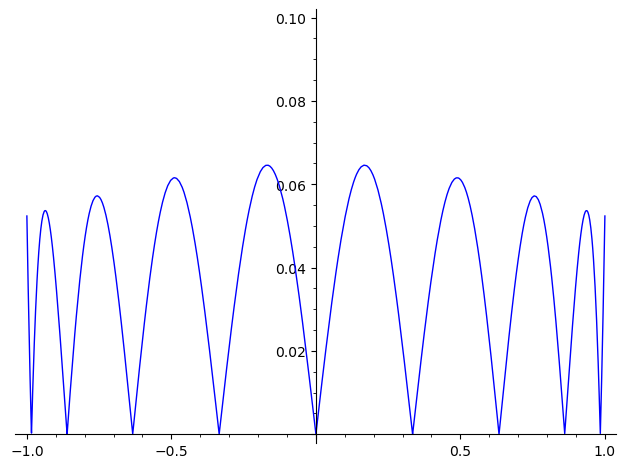

In [ ]:
errA = lambda z: abs(f(z) - A(x = z))
plot(errA(x), (x, -1, 1), ymax=0.1)

We see that we need a 9-th degree Chebyshev polynomials in the basis.

### Assignment Two

1. Consider $f(x) = \sin(2 \pi x)$ over $[-1,+1]$.  Use the first 16 Chebyshev polynomials to compute a least squares approximation for $f$.

2. What is the error?

### answer to assignment two

In [ ]:
f(x) = sin(2*pi*x)

In [ ]:
T = [chebyshev_T(k, x) for k in range(16)]
T

[1,
 x,
 2*x^2 - 1,
 4*x^3 - 3*x,
 8*x^4 - 8*x^2 + 1,
 16*x^5 - 20*x^3 + 5*x,
 32*x^6 - 48*x^4 + 18*x^2 - 1,
 64*x^7 - 112*x^5 + 56*x^3 - 7*x,
 128*x^8 - 256*x^6 + 160*x^4 - 32*x^2 + 1,
 256*x^9 - 576*x^7 + 432*x^5 - 120*x^3 + 9*x,
 512*x^10 - 1280*x^8 + 1120*x^6 - 400*x^4 + 50*x^2 - 1,
 1024*x^11 - 2816*x^9 + 2816*x^7 - 1232*x^5 + 220*x^3 - 11*x,
 2048*x^12 - 6144*x^10 + 6912*x^8 - 3584*x^6 + 840*x^4 - 72*x^2 + 1,
 4096*x^13 - 13312*x^11 + 16640*x^9 - 9984*x^7 + 2912*x^5 - 364*x^3 + 13*x,
 8192*x^14 - 28672*x^12 + 39424*x^10 - 26880*x^8 + 9408*x^6 - 1568*x^4 + 98*x^2 - 1,
 16384*x^15 - 61440*x^13 + 92160*x^11 - 70400*x^9 + 28800*x^7 - 6048*x^5 + 560*x^3 - 15*x]

In [ ]:
F = [fast_callable(p, vars='x') for p in T]

In [ ]:
ipft = [inner_product(f, T) for T in F]
ipft

[(0.0, 7.459000730499313e-15),
 (-0.4247650601527382, 1.7577840453197936e-14),
 (0.0, 9.082313396718633e-14),
 (-0.0582243920785146, 1.1347219099760717e-13),
 (0.0, 9.438212791613082e-13),
 (0.7456493159369406, 5.733434279864011e-15),
 (0.0, 6.712466112689804e-15),
 (-0.315042260224786, 9.93701217291686e-15),
 (0.0, 3.3909277583292514e-14),
 (0.05824776827954421, 9.869219843353269e-14),
 (0.0, 1.4090251276300887e-13),
 (-0.006295650484748561, 6.421760048515432e-13),
 (0.0, 5.177645771141176e-13),
 (0.0004527711747479568, 9.859972294603532e-13),
 (8.673617379884035e-18, 8.101537814524105e-13),
 (-2.3376886493793603e-05, 1.7446438961538916e-13)]

In [ ]:
a = [ip for (ip, err) in ipft]
A = a[0]/2 + sum([a*t for (a, t) in zip(a[1:], T[1:])])
A

-0.3830069083143144*x^15 + (7.105427357601002e-14)*x^14 + 3.29082663794631*x^13 - (2.4868995751603507e-13)*x^12 - 14.628449833895345*x^11 + (3.419486915845482e-13)*x^10 + 41.819825601584334*x^9 - (2.3314683517128287e-13)*x^8 - 76.63569268816057*x^7 + (8.1601392309949e-14)*x^6 + 81.59425256452091*x^5 - (1.3600232051658168e-14)*x^4 - 41.34092552387566*x^3 + (8.500145032286355e-16)*x^2 + 6.283169265758273*x - 8.673617379884035e-18

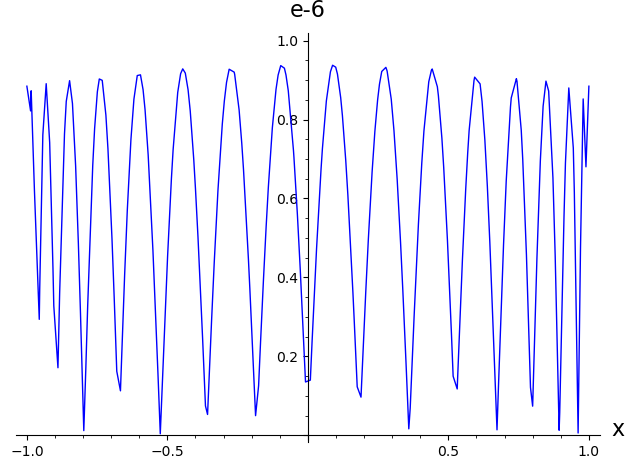

In [ ]:
errA = lambda z: abs(f(z) - A(x = z))
plot(errA(x), (x, -1, 1), ymax=1.0e-6, axes_labels=['x', 'e-6'])

Using the first 16 Chebyshev polynomials, the error of the approximation is $10^{-6}$.

## 3. Shifted Chebyshev polynomials

For functions that have a singularity in the middle of $[-1,+1]$,
such as $\sqrt{x}$,
it is better to consider $[0, 1]$ as the interval and work with
shifted Chebyshev polynomials.

The shifted Chebyshev polynomials are $T_n^*(x) = T_n(2 x - 1)$,
defined over the interval $[0,1]$, forming an orthogonal basis
with respect to the weight

$$
    w(x) = \frac{1}{\sqrt{x-x^2}}.
$$

### Assignment Three

1. Define the sequence of the first 10 shifted Chebyshev polynomials and their corresponding list of fast callables.

2. Adjust the function ``inner_product`` into a new function ``shifted_inner_product``, changing the integration interval from $[-1,+1]$ into $[0, 1]$.

3. Verify the orthogonality of the basis by computing the 10-by-10 table of all inner products, along with the estimates for the errors. 

### answer to assignment three

In [ ]:
T = [chebyshev_T(k, x) for k in range(10)]
T

[1,
 x,
 2*x^2 - 1,
 4*x^3 - 3*x,
 8*x^4 - 8*x^2 + 1,
 16*x^5 - 20*x^3 + 5*x,
 32*x^6 - 48*x^4 + 18*x^2 - 1,
 64*x^7 - 112*x^5 + 56*x^3 - 7*x,
 128*x^8 - 256*x^6 + 160*x^4 - 32*x^2 + 1,
 256*x^9 - 576*x^7 + 432*x^5 - 120*x^3 + 9*x]

In [ ]:
S2 = T[2](x = 2*x - 1)
show(S2)

2*(2*x - 1)^2 - 1

In [ ]:
S = [t(x=2*x-1).expand() for t in T]
S

[1,
 2*x - 1,
 8*x^2 - 8*x + 1,
 32*x^3 - 48*x^2 + 18*x - 1,
 128*x^4 - 256*x^3 + 160*x^2 - 32*x + 1,
 512*x^5 - 1280*x^4 + 1120*x^3 - 400*x^2 + 50*x - 1,
 2048*x^6 - 6144*x^5 + 6912*x^4 - 3584*x^3 + 840*x^2 - 72*x + 1,
 8192*x^7 - 28672*x^6 + 39424*x^5 - 26880*x^4 + 9408*x^3 - 1568*x^2 + 98*x - 1,
 32768*x^8 - 131072*x^7 + 212992*x^6 - 180224*x^5 + 84480*x^4 - 21504*x^3 + 2688*x^2 - 128*x + 1,
 131072*x^9 - 589824*x^8 + 1105920*x^7 - 1118208*x^6 + 658944*x^5 - 228096*x^4 + 44352*x^3 - 4320*x^2 + 162*x - 1]

In [ ]:
G = [fast_callable(p, vars='x') for p in S]

In [ ]:
[g(x) for g in G] 

[1,
 2*x - 1,
 8*x^2 - 8*x + 1,
 32*x^3 - 48*x^2 + 18*x - 1,
 128*x^4 - 256*x^3 + 160*x^2 - 32*x + 1,
 512*x^5 - 1280*x^4 + 1120*x^3 - 400*x^2 + 50*x - 1,
 2048*x^6 - 6144*x^5 + 6912*x^4 - 3584*x^3 + 840*x^2 - 72*x + 1,
 8192*x^7 - 28672*x^6 + 39424*x^5 - 26880*x^4 + 9408*x^3 - 1568*x^2 + 98*x - 1,
 32768*x^8 - 131072*x^7 + 212992*x^6 - 180224*x^5 + 84480*x^4 - 21504*x^3 + 2688*x^2 - 128*x + 1,
 131072*x^9 - 589824*x^8 + 1105920*x^7 - 1118208*x^6 + 658944*x^5 - 228096*x^4 + 44352*x^3 - 4320*x^2 + 162*x - 1]

In the computation of the inner product, we change the integration interval from $[-1,+1]$ to $[0, 1]$ and leave everything else the same.

In [ ]:
def shifted_inner_product(f, g):
    """
    Wraps quad of scipy.integrate to compute
    the inner product of functions f with g.
    Returns a tuple with the value and an
    estimate of the error.
    """
    from numpy import pi
    from scipy.integrate import quad
    #t = lambda x: (x+1)/2
    integrand = lambda x: 2.0*f(x)*g(x)/pi
    return quad(integrand,0,1, limit=100, epsabs=1.0e-12, epsrel=1.0e-12, weight='alg', wvar=(-0.5, -0.5))

In [ ]:
shifted_inner_product(G[1], G[1])

(1.0000000000000007, 7.205347429817266e-14)

In [ ]:
IPT = []
for f in G:
    IPT.append([shifted_inner_product(f, g) for g in G])

In [ ]:
print('the inner products :')
for row in IPT:
    for item in row:
        print(npfmt(item[0], sign=True,unique=False, precision=1), end=' ')
    print('')

the inner products :
+2.0e+00 +0.0e+00 -8.0e-17 -2.8e-16 +4.5e-16 +1.7e-14 +1.3e-13 -1.6e-13 +1.0e-12 +6.9e-13 
+0.0e+00 +1.0e+00 -2.8e-17 -2.7e-16 +3.8e-16 +1.6e-14 +1.2e-13 -1.5e-13 +3.9e-13 +1.8e-12 
-8.0e-17 -2.8e-17 +1.0e+00 -2.2e-16 -2.5e-16 +1.6e-14 +1.0e-13 -1.8e-13 -3.4e-14 +5.0e-12 
-2.8e-16 -2.7e-16 -2.2e-16 +1.0e+00 -1.2e-15 -3.5e-15 -3.3e-15 -3.3e-14 -5.0e-13 -4.2e-12 
+4.5e-16 +3.8e-16 -2.5e-16 -1.2e-15 +1.0e+00 +9.4e-16 -3.2e-14 +4.9e-15 -3.1e-13 -6.7e-13 
+1.7e-14 +1.6e-14 +1.6e-14 -3.5e-15 +9.4e-16 +1.0e+00 -2.5e-14 +1.3e-13 -2.7e-13 -8.8e-13 
+1.3e-13 +1.2e-13 +1.0e-13 -3.3e-15 -3.2e-14 -2.5e-14 +1.0e+00 +3.1e-13 +2.1e-13 +7.8e-12 
-1.6e-13 -1.5e-13 -1.8e-13 -3.3e-14 +4.9e-15 +1.3e-13 +3.1e-13 +1.0e+00 +2.7e-13 +6.4e-12 
+1.0e-12 +3.9e-13 -3.4e-14 -5.0e-13 -3.1e-13 -2.7e-13 +2.1e-13 +2.7e-13 +1.0e+00 +3.0e-12 
+6.9e-13 +1.8e-12 +5.0e-12 -4.2e-12 -6.7e-13 -8.8e-13 +7.8e-12 +6.4e-12 +3.0e-12 +1.0e+00 


We have computed a numerical approximation of the identity matrix, with the exception of the very first element, which equals 2, in agreement with the definition of the inner product.

In [ ]:
print('the error estimates :')
for row in IPT:
    for item in row:
        print(npfmt(item[1], sign=True,unique=False, precision=1), end=' ')
    print('')

the error estimates :
+6.5e-14 +6.8e-14 +7.9e-14 +1.0e-13 +1.5e-13 +2.4e-13 +3.8e-13 +9.1e-13 +8.3e-13 +8.8e-13 
+6.8e-14 +7.2e-14 +8.6e-14 +1.2e-13 +1.8e-13 +3.3e-13 +7.3e-13 +9.2e-13 +5.8e-13 +9.6e-13 
+7.9e-14 +8.6e-14 +1.1e-13 +1.6e-13 +2.8e-13 +5.7e-13 +7.5e-13 +8.4e-13 +6.0e-13 +4.4e-13 
+1.0e-13 +1.2e-13 +1.6e-13 +2.7e-13 +5.6e-13 +7.8e-13 +2.6e-13 +8.5e-13 +7.3e-13 +5.1e-13 
+1.5e-13 +1.8e-13 +2.8e-13 +5.6e-13 +7.6e-13 +2.9e-13 +5.8e-13 +3.5e-13 +1.3e-13 +8.7e-13 
+2.4e-13 +3.3e-13 +5.7e-13 +7.8e-13 +2.9e-13 +5.8e-13 +6.3e-13 +2.7e-13 +8.1e-13 +8.5e-13 
+3.8e-13 +7.3e-13 +7.5e-13 +2.6e-13 +5.8e-13 +6.3e-13 +1.0e-13 +6.5e-13 +6.7e-13 +7.6e-13 
+9.1e-13 +9.2e-13 +8.4e-13 +8.5e-13 +3.5e-13 +2.7e-13 +6.5e-13 +5.9e-13 +7.1e-13 +8.7e-13 
+8.3e-13 +5.8e-13 +6.0e-13 +7.3e-13 +1.3e-13 +8.1e-13 +6.7e-13 +7.1e-13 +7.8e-13 +8.0e-13 
+8.8e-13 +9.6e-13 +4.4e-13 +5.1e-13 +8.7e-13 +8.5e-13 +7.6e-13 +8.7e-13 +8.0e-13 +9.9e-13 


As observed with the Chebyshev basis, all error estimates for the integrals are tiny.

### Assignment Four

1. Consider $f(x) = \exp{x}$ and use the first 16 shifted Chebyshev polynomials to compute a least squares approximation for $f$ over $[0, 1]$.  

2. What is the error?  Compare with the error of the least squares approximation in the Chebyshev basis for $f$ over $[-1, 1]$.

### answer to assignment four

In [ ]:
f(x) = exp(x)

In [ ]:
ipft = [shifted_inner_product(f, g) for g in G]
ipft

[(3.506775308754182, 1.20570220474292e-13),
 (0.8503916537808108, 1.2734258092450546e-13),
 (0.10520869363093718, 1.5104584250025255e-13),
 (0.008722104733314862, 2.0000667788622195e-13),
 (0.0005434368311512672, 2.956732081393909e-13),
 (2.71154349586189e-05, 4.805877917846146e-13),
 (1.1281332190117566e-06, 8.388151284677292e-13),
 (4.024508182265407e-08, 1.5511838619056676e-13),
 (1.2578424690712353e-09, 7.728190428194436e-13),
 (1.4958050423286018e-11, 9.348304201354524e-13)]

In [ ]:
a = [ip for (ip, err) in ipft]
A = a[0]/2 + sum([a*s for (a, s) in zip(a[1:], S[1:])])
A

(1.960581585080945e-06)*x^9 + (3.2394364893661987e-05)*x^8 + 0.00018136218930919767*x^7 + 0.0014076940180416386*x^6 + 0.008321637423413186*x^5 + 0.041670877311064114*x^4 + 0.1666658208928512*x^3 + 0.5000000849265902*x^2 + 0.9999999967104999*x + 1.0000000000211169

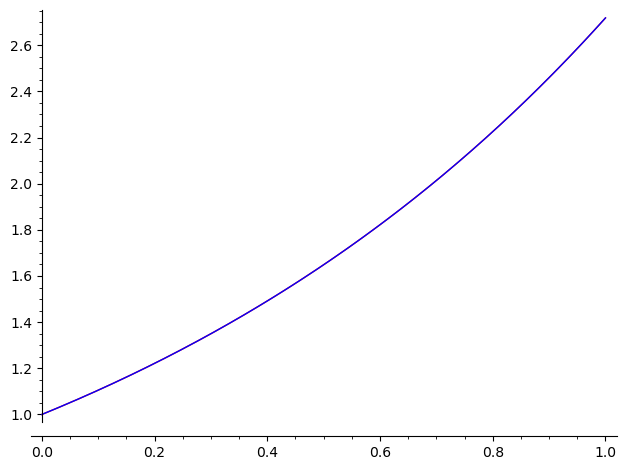

In [ ]:
pA = plot(A, (x, 0, 1), color='red')
pf = plot(f, (x, 0, 1))
show(pA + pf)

In [ ]:
errA(z) = abs(f(x=z) - A(x = z))

In [ ]:
[errA(k*0.1) for k in range(10)]

[2.1116886017580327e-11,
 1.69391167759159e-11,
 7.28683779982475e-12,
 1.22430954263564e-11,
 1.82567294615410e-11,
 1.80033765673215e-12,
 1.93360882860816e-11,
 9.29256671611256e-12,
 1.05671027483822e-11,
 1.80988557474393e-11]

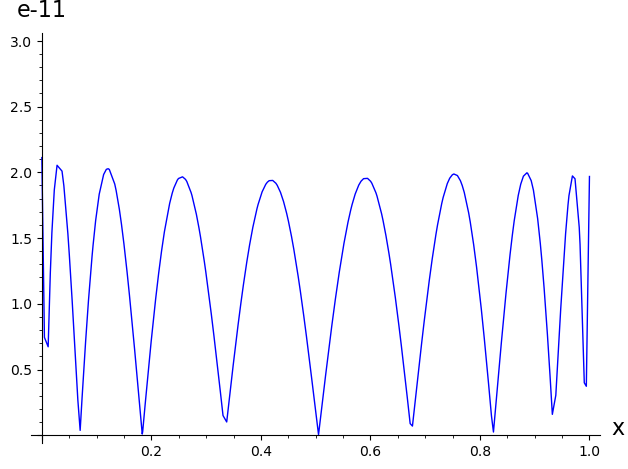

In [ ]:
plot(errA(x), (x, 0.0, 1.0), ymin=0, ymax=3.0e-11, axes_labels=['x', 'e-11'])

We see that the error on $[0,1]$ is less than $3 \times 10^{-11}$.  This is better than the $6 \times 10^{-10}$ on $[-1, 1]$, as we have gained about one extra decimal place of accuracy.

### Assignment Five

1. Consider $f(x) = \sqrt{x}$ and use the first 16 shifted Chebyshev polynomials to compute a least squares approximation for $f$.

2. What is the error?

### answer to assignment five

We start by setting up the basis.

In [ ]:
T = [chebyshev_T(k, x) for k in range(16)]
S = [t(x=2*x-1).expand() for t in T]
G = [fast_callable(p, vars='x') for p in S]

In [ ]:
f(x) = sqrt(x)

In [ ]:
ipft = [shifted_inner_product(f, g) for g in G]

/tmp/ipykernel_15741/1847448294.py:12: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  return quad(integrand,Integer(0),Integer(1), limit=Integer(100), epsabs=RealNumber('1.0e-12'), epsrel=RealNumber('1.0e-12'), weight='alg', wvar=(-RealNumber('0.5'), -RealNumber('0.5')))


We will be able to safely ignore this error, as shown in the error plot below.

In [ ]:
a = [ip for (ip, err) in ipft]
A = a[0]/2 + sum([a*s for (a, s) in zip(a[1:], S[1:])])
A

760425.895266369*x^15 - 5921447.082152192*x^14 + 20839343.661522992*x^13 - 43819639.35129244*x^12 + 61324082.646249786*x^11 - 60219013.75054225*x^10 + 42625428.87945318*x^9 - 21997660.642704062*x^8 + 8276668.2769985255*x^7 - 2247759.8290439523*x^6 + 431709.82807732077*x^5 - 56766.6324518453*x^4 + 4879.899368442426*x^3 - 260.67601940638303*x^2 + 9.857394737056321*x + 0.020535995734527912

In [ ]:
errA(z) = abs(f(x=z) - A(x = z))

In [ ]:
[errA(k*0.1) for k in range(10)]

[0.020535995734527912,
 0.000727279791286284,
 0.00144689172403201,
 0.000991327552336108,
 0.000775497027475813,
 0.000699011117268333,
 0.000643989855640292,
 0.000527160918324832,
 0.000195437601571702,
 0.000586210054666081]

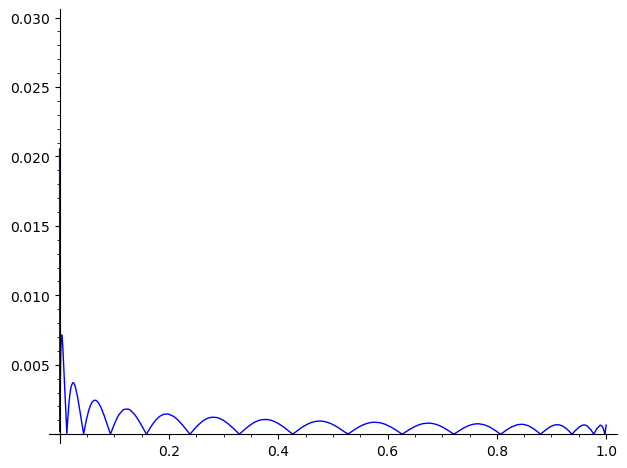

In [ ]:
plot(errA(x), (x, 0.0, 1.0), ymax=0.03)

We see that the error on $[0, 1]$ is less than $3 \times 10^{-3}$ and it drops by one magnitude in $[0.1, 1]$.